In [ ]:
pip install prophet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("household_power_consumption.txt", sep=';', low_memory=False)


In [3]:
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df = df[['datetime', 'Global_active_power']]
df = df.dropna()

C:\Users\INTEL\AppData\Local\Temp\ipykernel_248\2519055957.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')


In [4]:
df.set_index('datetime', inplace=True)
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df = df.dropna()


In [5]:
df_hourly = df.resample('H').mean().dropna()


C:\Users\INTEL\AppData\Local\Temp\ipykernel_248\3964279280.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean().dropna()


In [13]:
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day'] = df_hourly.index.day
df_hourly['weekday'] = df_hourly.index.weekday
df_hourly['is_weekend'] = df_hourly['weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [7]:
train = df_hourly[:'2010-01-01']
test = df_hourly['2010-01-02':]

In [8]:
arima_model = ARIMA(train['Global_active_power'], order=(5,1,0))
arima_fit = arima_model.fit()
pred_arima = arima_fit.forecast(steps=len(test))


C:\Users\INTEL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\INTEL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\INTEL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\INTEL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\U

In [9]:
prophet_df = df_hourly.reset_index()[['datetime', 'Global_active_power']]
prophet_df.columns = ['ds', 'y']

In [10]:
train_p = prophet_df[prophet_df['ds'] <= '2010-01-01']
test_p = prophet_df[prophet_df['ds'] > '2010-01-01']

In [11]:
model_prophet = Prophet()
model_prophet.fit(train_p)

16:39:13 - cmdstanpy - INFO - Chain [1] start processing
16:39:28 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
future = model_prophet.make_future_dataframe(periods=len(test_p), freq='H')
forecast = model_prophet.predict(future)

C:\Users\INTEL\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [14]:
forecast = forecast[['ds', 'yhat']]


In [15]:
merged_prophet = test_p.merge(forecast, on='ds', how='inner')


In [16]:
pred_prophet = merged_prophet['yhat'].values
y_true_prophet = merged_prophet['y'].values

In [17]:
features = ['hour', 'day', 'weekday', 'is_weekend']


In [18]:
X_train = train[features]
y_train = train['Global_active_power']

In [19]:
X_test = test[features]
y_test = test['Global_active_power']

In [20]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [21]:
pred_xgb = xgb_model.predict(X_test)


In [22]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [23]:
test_prophet_true = test['Global_active_power'].values[:len(pred_prophet)]

print("ARIMA MAE, RMSE:", evaluate(test['Global_active_power'], pred_arima))
print("PROPHET MAE, RMSE:", evaluate(test_prophet_true, pred_prophet))
print("XGBOOST MAE, RMSE:", evaluate(y_test, pred_xgb))


ARIMA MAE, RMSE: (0.6612394078912369, np.float64(0.9457443786139633))
PROPHET MAE, RMSE: (0.5412144406266254, np.float64(0.7046457119049379))
XGBOOST MAE, RMSE: (0.5156387429617159, np.float64(0.6971785976115097))


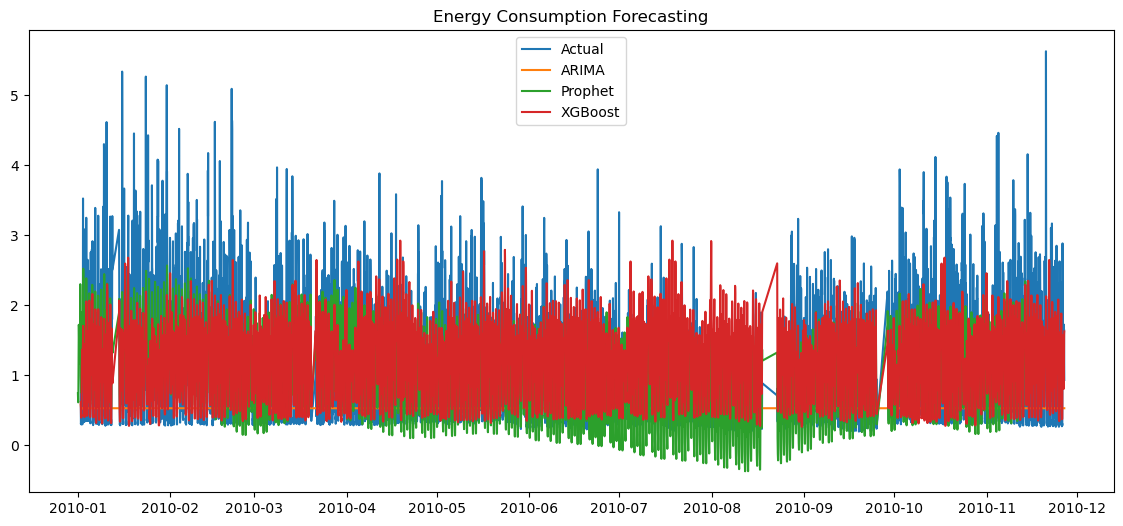

In [26]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test['Global_active_power'], label='Actual')
plt.plot(test.index, pred_arima, label='ARIMA')
plt.plot(merged_prophet['ds'], pred_prophet, label='Prophet')
plt.plot(test.index, pred_xgb, label='XGBoost')

plt.legend()
plt.title("Energy Consumption Forecasting")
plt.show()